# Building codes

In [1]:
import os
import random
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
import gc
import threading
from transformers import AutoProcessor, AutoModel
from tqdm import tqdm
from pathlib import Path
import io
from io import BytesIO
import fitz
import base64
from PIL import Image
import concurrent.futures
from concurrent.futures import ThreadPoolExecutor
import multiprocessing

os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"

device = 'cuda' if torch.cuda.is_available() else 'cpu'
revision_id = "344d954da76eb8ad47a7aaff42d012e30c15b8fe"

model = SentenceTransformer(
    "LocalModels/jina-clip-v2-local", 
    device=device,
    revision=revision_id,
    trust_remote_code=True, 
    truncate_dim=384,
    local_files_only=True
)

INDEX_FILE = 'building_codes_embeddings.parquet'

def pdf_to_base64_pngs(pdf_path, max_size=(1024, 1024)):
    # Open the PDF file
    doc = fitz.open(pdf_path)
    
    def process_page(page_num):
        # Load the page
        page = doc.load_page(page_num)
        
        # Calculate scale to fit max_size while preserving aspect ratio
        rect = page.rect
        scale = min(max_size[0] / rect.width, max_size[1] / rect.height)
        
        # Render the page as a PNG pixmap at the target scale
        pix = page.get_pixmap(matrix=fitz.Matrix(scale, scale))
        
        # Get PNG bytes directly and encode to base64
        png_bytes = pix.tobytes("png")
        return base64.b64encode(png_bytes).decode('utf-8')
    
    # Process pages in parallel using threads (thread-safe for PyMuPDF reads)
    base64_encoded_pngs = [None] * doc.page_count
    futures_to_page = {}
    
    with concurrent.futures.ThreadPoolExecutor(max_workers=multiprocessing.cpu_count()) as executor:
        for page_num in range(doc.page_count):
            future = executor.submit(process_page, page_num)
            futures_to_page[future] = page_num
        
        for future in tqdm(concurrent.futures.as_completed(futures_to_page), total=doc.page_count, desc="Processing pages"):
            page_num = futures_to_page[future]
            base64_encoded_pngs[page_num] = future.result()
    
    # Close the PDF document
    doc.close()
    
    return base64_encoded_pngs

def base64_to_pillow(base64_string):
    """
    Decodes a Base64 string and converts it into a Pillow Image object.

    Args:
        base64_string (str): The Base64 encoded image string.

    Returns:
        PIL.Image.Image: A Pillow Image object, or None if an error occurs.
    """
    # Remove data URI prefix if it exists (e.g., "data:image/png;base64,")
    if "base64," in base64_string:
        base64_string = base64_string.split("base64,")[1]

    try:
        # Decode the Base64 string into bytes
        image_bytes = base64.b64decode(base64_string)

        # Create an in-memory binary stream from the bytes
        image_stream = BytesIO(image_bytes)

        # Open the image using Pillow
        image = Image.open(image_stream)
        return image

    except Exception as e:
        print(f"Error converting Base64 to Pillow Image: {e}")
        return None

b64s = pdf_to_base64_pngs("BuildingCodes/2021_International_Building_Code.pdf")
IMAGE_EMBEDDINGS = []
for i, b64 in enumerate(tqdm(b64s, total=len(b64s))):
    img = base64_to_pillow(b64)
    with torch.no_grad():
        img_emb = model.encode(img, show_progress_bar=False, convert_to_tensor=True)
        IMAGE_EMBEDDINGS.append(img_emb)

Skipping import of cpp extensions due to incompatible torch version 2.8.0 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info
W1230 14:07:41.875000 70745 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
100%|███████████████████████████████████████| 833/833 [21:11<00:00,  1.53s/it]


In [29]:
import faiss
import numpy as np

# Build FAISS index once (after indexing all PDFs)
def build_faiss_index(parquet_path: str, index_path: str = "building_codes.faiss"):
    df = pd.read_parquet(parquet_path)
    embeddings = np.stack(df['embedding'].values).astype('float32')
    
    # Normalize for cosine similarity
    faiss.normalize_L2(embeddings)
    
    # Choose index type:
    # For high accuracy + speed on <100k vectors:
    index = faiss.IndexFlatIP(embeddings.shape[1])  # Inner Product = cosine after L2 norm
    
    # For millions of vectors (faster, approximate):
    # nlist = 100
    # quantizer = faiss.IndexFlatIP(dim)
    # index = faiss.IndexIVFFlat(quantizer, dim, nlist)
    # index.train(embeddings)
    
    index.add(embeddings)
    faiss.write_index(index, index_path)
    print(f"FAISS index saved to {index_path}")

# Updated retrieval using FAISS
def retrieve_page_indices(
    query: str,
    faiss_index_path: str = "building_codes.faiss",
    parquet_path: str = "building_codes_embeddings.parquet",
    top_k: int = 10,
    top_p: float = 1.0
) -> list[int]:
    # Load index once or cache it
    index = faiss.read_index(faiss_index_path)
    
    # Load only metadata (not embeddings)
    df = pd.read_parquet(parquet_path, columns=['pdf_source', 'page_number'])
    
    with torch.no_grad():
        query_emb = retrieval_model.encode(
            query,
            convert_to_tensor=True,
            normalize_embeddings=True
        ).cpu().numpy().astype('float32')
    
    # Ensure shape is (1, dim)
    if query_emb.ndim == 1:
        query_emb = query_emb.reshape(1, -1)
    
    faiss.normalize_L2(query_emb)
    
    search_k = top_k * 4 if top_p < 1.0 else top_k
    scores, indices = index.search(query_emb, search_k)
    scores = scores.flatten()
    indices = indices.flatten()
    
    # Optional: top-p filtering on scores
    if top_p < 1.0:
        # Softmax to probabilities
        probs = np.exp(scores - scores.max())
        probs /= probs.sum()
        sorted_idx = np.argsort(probs)[::-1]
        cum_probs = np.cumsum(probs[sorted_idx])
        keep = cum_probs <= top_p
        if not keep.any():
            keep[0] = True
        indices = indices[sorted_idx][keep]
        scores = scores[sorted_idx][keep]
    
    final_indices = sorted(indices[:top_k].tolist())
    
    return final_indices

In [66]:
# Load full dataframe once (for later use)
EMBEDDINGS_FILE = "building_codes_embeddings.parquet"
build_faiss_index(parquet_path=EMBEDDINGS_FILE)
df = pd.read_parquet(EMBEDDINGS_FILE)

# Retrieve top matching page indices
indices = retrieve_page_indices(
    query="屋顶光伏安装的要求",
    top_k=7,
    top_p=0.95
)

print("Top matching pages (index, pdf, page number, score):")
for idx in indices:
    row = df.iloc[idx]
    # You'd need to compute score again or store it, but here's a quick way:
    # (Alternatively, modify function to return scores too if needed)
    print(f"Index {idx}: {row['pdf_source']} - Page {row['page_number']}")
    
    # Now easily get image if you stored base64:
    # img = base64_to_pillow(row['base64_png'])
    # img.show()

FAISS index saved to building_codes.faiss
Top matching pages (index, pdf, page number, score):
Index 206: 2021_International_Building_Code.pdf - Page 207
Index 207: 2021_International_Building_Code.pdf - Page 208
Index 209: 2021_International_Building_Code.pdf - Page 210
Index 210: 2021_International_Building_Code.pdf - Page 211
Index 212: 2021_International_Building_Code.pdf - Page 213
Index 221: 2021_International_Building_Code.pdf - Page 222
Index 223: 2021_International_Building_Code.pdf - Page 224


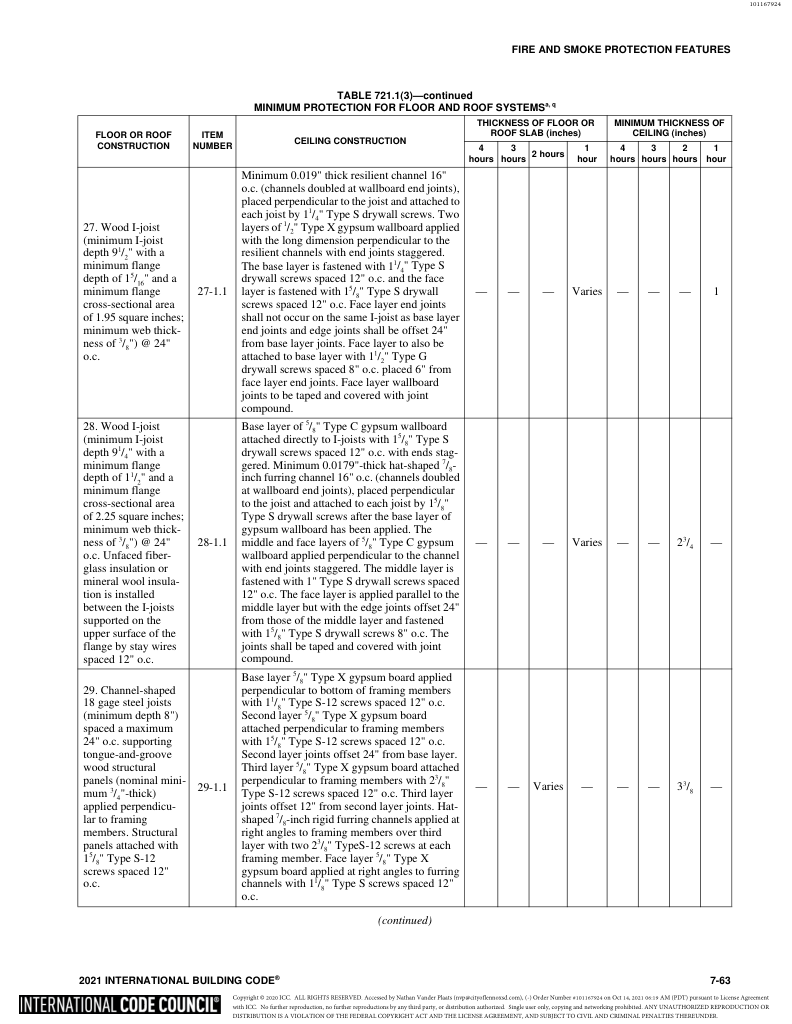

In [69]:
base64_to_pillow(b64s[223])
# sorted(indices)

In [5]:
# import requests
# from PIL import Image
# import torch.nn.functional as F

# image = Image.open(requests.get("https://huggingface.co/datasets/merve/coco/resolve/main/val2017/000000000285.jpg", stream=True).raw)

# with torch.no_grad():
#     image_emb = model.encode(image, show_progress_bar=False, convert_to_tensor=True)

# candidate_labels = ["2 cats", "a plane", "a remote"]
# # text_inputs = processor(text=candidate_labels, padding="max_length", return_tensors="pt").to(model.device)
# with torch.no_grad():
#     # text_emb = model.get_text_features(**text_inputs)
#     text_emb = model.encode(candidate_labels, convert_to_tensor=True)


# # Normalize embeddings for cosine similarity (L2 norm)
# image_emb_norm = F.normalize(image_emb, dim=-1)
# text_emb_norm = F.normalize(text_emb, dim=-1)

# # Compute cosine similarities (dot product of normalized vectors)
# similarities = F.cosine_similarity(image_emb_norm, text_emb_norm, dim=-1)

# # Find the index of the highest similarity
# best_idx = similarities.argmax().item()
# best_label = candidate_labels[best_idx]
# best_score = similarities[best_idx].item()

# print(f"Predicted label: '{best_label}' (score: {best_score:.4f})")
# print("All similarities:", {label: score.item() for label, score in zip(candidate_labels, similarities)})

# Agent workflow

In [6]:
import os
import io
import base64
from PIL import Image
from openai import OpenAI
from dotenv import load_dotenv
import requests
from urllib.parse import urlparse
import argparse
import sys
import yaml
import dspy

load_dotenv()

# Initialize the OpenAI Client
client = OpenAI(
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("BASE_URL")
)

lm = dspy.LM(f"openai/{os.getenv("TEXT_MODEL")}", api_key=os.getenv("DASHSCOPE_API_KEY"), base_url=os.getenv("BASE_URL"))
dspy.configure(lm=lm)

In [7]:
def evaluate_math(expression: str):
    return dspy.PythonInterpreter({}).execute(expression)

def search_wikipedia(query: str):
    results = dspy.ColBERTv2(url="http://20.102.90.50:2017/wiki17_abstracts")(query, k=3)
    return [x["text"] for x in results]

react = dspy.ReAct("question -> answer: float", tools=[evaluate_math, search_wikipedia])

pred = react(question="What is 9362158 divided by the year of birth of David Gregory of Kinnairdy castle?")
print(pred.answer)

5761.328


In [72]:
from openai import OpenAI
import os

# Initialize OpenAI client
client = OpenAI(
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("BASE_URL")
)

reasoning_content = ""   # Define complete reasoning process
answer_content = ""      # Define complete response
is_answering = False     # Determine if reasoning has ended and response has started
enable_thinking = False

# Create chat completion request
completion = client.chat.completions.create(
    model="qwen3-vl-plus",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": "https://img.alicdn.com/imgextra/i1/O1CN01gDEY8M1W114Hi3XcN_!!6000000002727-0-tps-1024-406.jpg"
                    },
                },
                {"type": "text", "text": "How to solve this problem?"},
            ],
        },
    ],
    stream=True,
    # enable_thinking parameter enables reasoning; thinking_budget sets the maximum token count for reasoning
    # qwen-vl-plus, qwen3-vl-plus-2025-09-23 can use enable_thinking to turn reasoning on/off;
    # qwen3-vl-235b-a22b-thinking supports enable_thinking, other Qwen-VL models do not support it
    extra_body={
        'enable_thinking': True,
        "thinking_budget": 500
    },

    # Uncomment below to return token usage in the final chunk
    # stream_options={
    #     "include_usage": True
    # }
)

if enable_thinking:
    print("\n" + "=" * 20 + "Reasoning Process" + "=" * 20 + "\n")

for chunk in completion:
    # If chunk.choices is empty, print usage
    if not chunk.choices:
        print("\nUsage:")
        print(chunk.usage)
    else:
        delta = chunk.choices[0].delta
        # Print reasoning process
        if hasattr(delta, 'reasoning_content') and delta.reasoning_content is not None:
            print(delta.reasoning_content, end='', flush=True)
            reasoning_content += delta.reasoning_content
        else:
            # Start response
            if delta.content != "" and is_answering is False:
                print("\n" + "=" * 20 + "Complete Response" + "=" * 20 + "\n")
                is_answering = True
            # Print response process
            if delta.content is not None:
                print(delta.content, end='', flush=True)
                answer_content += delta.content

# Optional: print full reasoning and answer at the end
# print("=" * 20 + "Complete Reasoning Process" + "=" * 20 + "\n")
# print(reasoning_content)
# print("=" * 20 + "Complete Response" + "=" * 20 + "\n")
# print(answer_content)

Got it, let's see. The problem is to calculate the surface area and volume of two 3D shapes: a rectangular prism (first one) and a cube (second one). Let's start with the first one.

First, for the rectangular prism. The formula for surface area of a rectangular prism is 2(lw + lh + wh), where l is length, w is width, h is height. Volume is lwh. Let's check the dimensions. The first figure has length 4 cm, width 3 cm, height 2 cm. Right?

So surface area: 2*(4*3 + 4*2 + 3*2). Let's calculate each part: 4*3=12, 4*2=8, 3*2=6. Sum is 12+8+6=26. Multiply by 2: 52 cm².

Volume: 4*3*2=24 cm³. That seems right.

Now the second figure is a cube with side length 3 cm. For a cube, surface area is 6s², where s is side length. Volume is s³.

Surface area: 6*(3*3)=6*9=54 cm².

Volume: 3*3*3=27 cm³.

Wait, let me double-check. For rectangular prism, yes, surface area is sum of all faces, each pair has two faces. So length*width*2 + length*height*2 + width*height*2, which is the same as 2(lw + lh + w

In [74]:
lm = dspy.LM(f"openai/{os.getenv("VISION_MODEL")}", api_key=os.getenv("DASHSCOPE_API_KEY"), base_url=os.getenv("BASE_URL"))
dspy.configure(lm=lm)

class Solver(dspy.Signature):
    question: str = dspy.InputField(desc="user's question")
    image: dspy.Image = dspy.InputField(desc="The image containing the problem to be solved")
    response: str = dspy.OutputField(desc="model's response")

cot = dspy.ChainOfThought(Solver)
query = "How to solve this problem?"
output = cot(question=query, image=dspy.Image.from_url("https://img.alicdn.com/imgextra/i1/O1CN01gDEY8M1W114Hi3XcN_!!6000000002727-0-tps-1024-406.jpg"))

In [77]:
print(output.response)

For the first figure (rectangular prism):
- Surface Area: 52 cm²
- Volume: 24 cm³

For the second figure (cube):
- Surface Area: 54 cm²
- Volume: 27 cm³
